In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from lifelines import KaplanMeierFitter

In [2]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)
library_path

PosixPath('/home/luis/CGE/PCI_survival/src')

In [3]:
# load data
DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"

cols_to_use = ["event", "months", "Sex", "Age", "Tumor"]

df = pd.read_csv(f"{DATA_PATH}/GPT_processed_survival_data.csv", usecols=cols_to_use)
df['months_round'] = df['months'].round().astype(int)

The cutoff value was found in the previous notebook.

In [4]:
t_cutoff = 57

In [5]:
df["months_trunc"] = df["months_round"].clip(upper=t_cutoff)
df["event_trunc"] = ((df["event"] == 1) & (df["months_round"] <= t_cutoff)).astype(int)

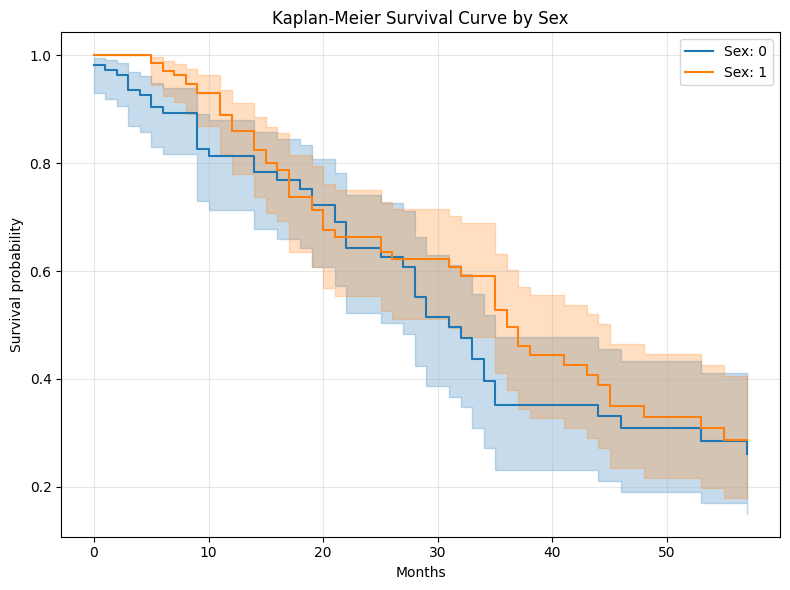

In [6]:
# KM curves by Sex
fig, ax = plt.subplots(figsize=(8, 6))

kmf = KaplanMeierFitter()

for sex_value in sorted(df["Sex"].dropna().unique()):
    mask = df["Sex"] == sex_value
    kmf.fit(
        durations=df.loc[mask, "months_trunc"],
        event_observed=df.loc[mask, "event_trunc"],
        label=f"Sex: {sex_value}"
    )
    kmf.plot_survival_function(ax=ax)

ax.set_title("Kaplan-Meier Survival Curve by Sex")
ax.set_xlabel("Months")
ax.set_ylabel("Survival probability")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

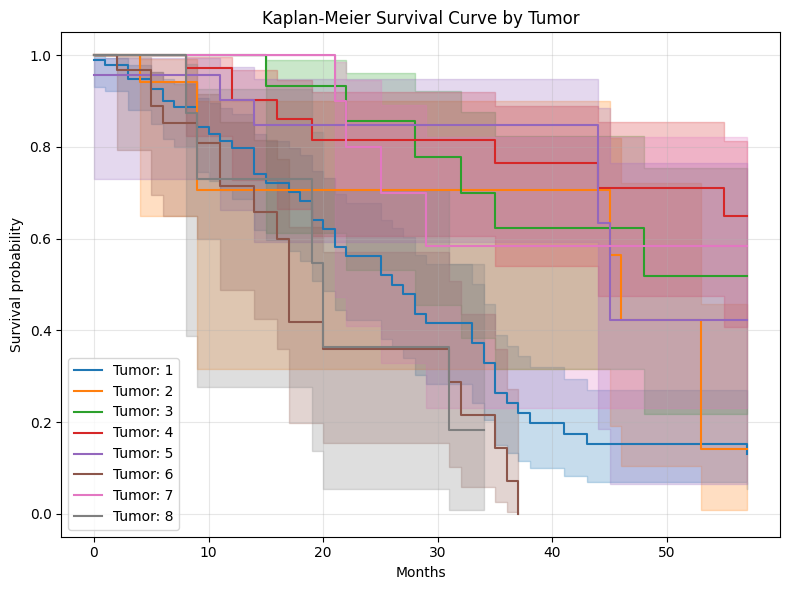

In [7]:
# KM curves by Tumor
fig, ax = plt.subplots(figsize=(8, 6))

kmf = KaplanMeierFitter()

for tumor_value in sorted(df["Tumor"].dropna().unique()):
    mask = df["Tumor"] == tumor_value
    kmf.fit(
        durations=df.loc[mask, "months_trunc"],
        event_observed=df.loc[mask, "event_trunc"],
        label=f"Tumor: {tumor_value}"
    )
    kmf.plot_survival_function(ax=ax)

ax.set_title("Kaplan-Meier Survival Curve by Tumor")
ax.set_xlabel("Months")
ax.set_ylabel("Survival probability")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Create age groups
df["Age_group"] = pd.qcut(
    df["Age"],
    q=3,
    labels=["Younger", "Middle", "Older"]
)

df["Age_group"].value_counts(dropna=False).sort_index()

Age_group
Younger    89
Middle     88
Older      87
Name: count, dtype: int64

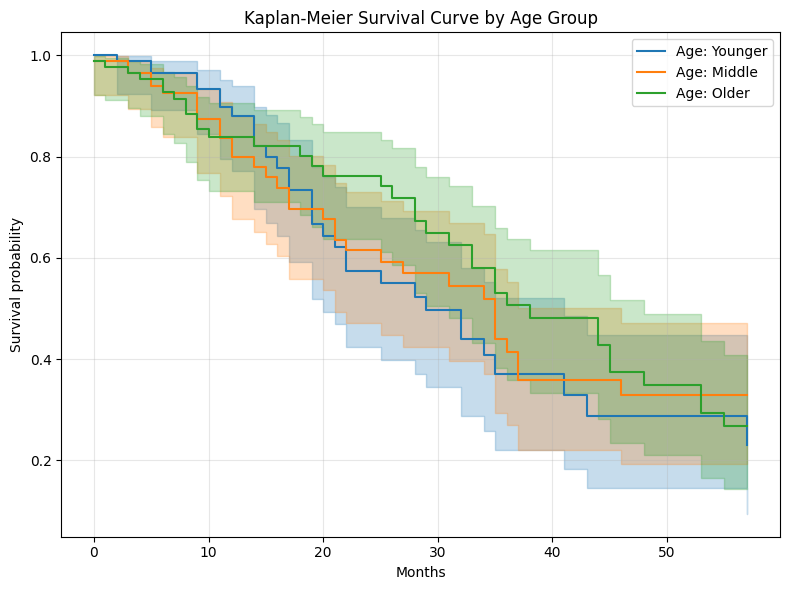

In [9]:
# KM curves by Age group
fig, ax = plt.subplots(figsize=(8, 6))

kmf = KaplanMeierFitter()

for age_group in df["Age_group"].dropna().cat.categories:
    mask = df["Age_group"] == age_group
    kmf.fit(
        durations=df.loc[mask, "months_trunc"],
        event_observed=df.loc[mask, "event_trunc"],
        label=f"Age: {age_group}"
    )
    kmf.plot_survival_function(ax=ax)

ax.set_title("Kaplan-Meier Survival Curve by Age Group")
ax.set_xlabel("Months")
ax.set_ylabel("Survival probability")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
from lifelines import CoxPHFitter

df_sex = df[["months_trunc", "event_trunc", "Sex"]].dropna().copy()
df_sex["Sex_code"] = pd.Categorical(df_sex["Sex"]).codes
df_sex = df_sex.drop(columns=["Sex"])

cph_sex = CoxPHFitter()
cph_sex.fit(df_sex, duration_col="months_trunc", event_col="event_trunc")

cph_sex.print_summary()
cph_sex.check_assumptions(df_sex, p_value_threshold=0.05, show_plots=False)

<lifelines.CoxPHFitter: fitted with 264 total observations, 163 right-censored observations>
             duration col = 'months_trunc'
                event col = 'event_trunc'
      baseline estimation = breslow
   number of observations = 264
number of events observed = 101
   partial log-likelihood = -461.62
         time fit was run = 2026-04-20 09:25:46 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Sex_code  -0.24      0.78      0.20           -0.63            0.15                0.53                1.16

           cmp to     z    p  -log2(p)
covariate                             
Sex_code     0.00 -1.21 0.23      2.14
---
Concordance = 0.56
Partial AIC = 925.25
log-likelihood ratio test = 1.45 on 1 df
-log2(p) of ll-ratio test = 2.13

Proportional hazard assumption looks okay.


[]

In [11]:
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test

In [12]:
# Log-rank test by Sex
sex_df = df[["months_trunc", "event_trunc", "Sex"]].dropna().copy()
sex_levels = sorted(sex_df["Sex"].unique())

# Quick power check
print("=== Sex group summary ===")
sex_summary = sex_df.groupby("Sex").agg(
    n=("event_trunc", "count"),
    events=("event_trunc", "sum")
).assign(event_rate=lambda x: x["events"] / x["n"])
display(sex_summary)

for grp, row in sex_summary.iterrows():
    status = "✓ OK" if row["events"] >= 10 else "⚠ Low"
    print(f"  {grp}: {int(row['events'])} events  {status}")

# Log-rank test
if len(sex_levels) == 2:
    g1, g2 = sex_levels
    result_sex = logrank_test(
        durations_A=sex_df.loc[sex_df["Sex"] == g1, "months_trunc"],
        durations_B=sex_df.loc[sex_df["Sex"] == g2, "months_trunc"],
        event_observed_A=sex_df.loc[sex_df["Sex"] == g1, "event_trunc"],
        event_observed_B=sex_df.loc[sex_df["Sex"] == g2, "event_trunc"],
    )
else:
    result_sex = multivariate_logrank_test(
        sex_df["months_trunc"],
        sex_df["Sex"],
        sex_df["event_trunc"],
    )

display(result_sex.summary)
print(f"Sex log-rank p-value: {result_sex.p_value:.4g}")

=== Sex group summary ===


,n,events,event_rate
Sex,,,
0,111,47,0.423423
1,153,54,0.352941


  0: 47 events  ✓ OK
  1: 54 events  ✓ OK


,test_statistic,p,-log2(p)
0,1.482381,0.223402,2.162284


Sex log-rank p-value: 0.2234


In [21]:
# Power analysis for log-rank test (Sex)
from scipy.stats import norm

sex_df = df[["months_trunc", "event_trunc", "Sex"]].dropna().copy()

print("=== Sex group summary ===")
sex_summary = sex_df.groupby("Sex").agg(
    n=("event_trunc", "count"),
    events=("event_trunc", "sum")
).assign(event_rate=lambda x: x["events"] / x["n"])
display(sex_summary)

# Total events
total_events = sex_df["event_trunc"].sum()
total_n = len(sex_df)
print(f"\nTotal N:      {total_n}")
print(f"Total events: {total_events} ({100 * total_events / total_n:.1f}%)")
print(f"\nRule of thumb: ≥10 events per group recommended for reliable log-rank test")

# Per-group event check
print("\n=== Events per group vs. threshold ===")
for grp, row in sex_summary.iterrows():
    status = "✓ OK" if row["events"] >= 10 else "⚠ Low"
    print(f"  {grp}: {int(row['events'])} events  {status}")

# Schoenfeld power estimate (2-group, so only one comparison)
print("\n=== Schoenfeld power estimate ===")
alpha = 0.05
z_alpha = norm.ppf(1 - alpha / 2)

groups = list(sex_summary.index)
g1, g2 = groups[0], groups[1]

n1 = sex_summary.loc[g1, "n"]
n2 = sex_summary.loc[g2, "n"]
p1 = n1 / (n1 + n2)  # proportion in group 1 — accounts for unequal group sizes

d = sex_summary["events"].sum()
hr = sex_summary.loc[g2, "event_rate"] / sex_summary.loc[g1, "event_rate"]

if hr == 0 or np.isnan(hr):
    print("  HR undefined (no events in one group)")
else:
    log_hr = abs(np.log(hr))
    # General Schoenfeld formula: sqrt(d * p1 * (1-p1)) * |log(HR)| - z_{alpha/2}
    power = norm.cdf(np.sqrt(d * p1 * (1 - p1)) * log_hr - z_alpha)
    print(f"  {g1} vs {g2}: d={int(d)}, HR={hr:.2f}, estimated power={power:.2%}")
    if power < 0.80:
        print(f"  ⚠ Power below 80% threshold — interpret log-rank result cautiously")
    else:
        print(f"  ✓ Sufficient power to detect observed effect size")

=== Sex group summary ===


,n,events,event_rate
Sex,,,
0,111,47,0.423423
1,153,54,0.352941



Total N:      264
Total events: 101 (38.3%)

Rule of thumb: ≥10 events per group recommended for reliable log-rank test

=== Events per group vs. threshold ===
  0: 47 events  ✓ OK
  1: 54 events  ✓ OK

=== Schoenfeld power estimate ===
  0 vs 1: d=101, HR=0.83, estimated power=14.53%
  ⚠ Power below 80% threshold — interpret log-rank result cautiously


In [14]:
# Log-rank test by Tumor
tumor_df = df[["months_trunc", "event_trunc", "Tumor"]].dropna().copy()
tumor_levels = sorted(tumor_df["Tumor"].unique())

# Group summary
print("=== Tumor group summary ===")
tumor_summary = tumor_df.groupby("Tumor").agg(
    n=("event_trunc", "count"),
    events=("event_trunc", "sum")
).assign(event_rate=lambda x: x["events"] / x["n"])
display(tumor_summary)

# Per-group event check
print("\n=== Events per group vs. threshold ===")
for grp, row in tumor_summary.iterrows():
    status = "✓ OK" if row["events"] >= 10 else "⚠ Low"
    print(f"  {grp}: {int(row['events'])} events  {status}")

# Log-rank test
if len(tumor_levels) == 2:
    g1, g2 = tumor_levels
    result_tumor = logrank_test(
        durations_A=tumor_df.loc[tumor_df["Tumor"] == g1, "months_trunc"],
        durations_B=tumor_df.loc[tumor_df["Tumor"] == g2, "months_trunc"],
        event_observed_A=tumor_df.loc[tumor_df["Tumor"] == g1, "event_trunc"],
        event_observed_B=tumor_df.loc[tumor_df["Tumor"] == g2, "event_trunc"],
    )
else:
    result_tumor = multivariate_logrank_test(
        tumor_df["months_trunc"],
        tumor_df["Tumor"],
        tumor_df["event_trunc"],
    )

display(result_tumor.summary)
print(f"Tumor log-rank p-value: {result_tumor.p_value:.4g}")



=== Tumor group summary ===


,n,events,event_rate
Tumor,,,
1,99,48,0.484848
2,18,7,0.388889
3,22,6,0.272727
4,48,8,0.166667
5,23,5,0.217391
6,31,18,0.580645
7,13,4,0.307692
8,10,5,0.500000



=== Events per group vs. threshold ===
  1: 48 events  ✓ OK
  2: 7 events  ⚠ Low
  3: 6 events  ⚠ Low
  4: 8 events  ⚠ Low
  5: 5 events  ⚠ Low
  6: 18 events  ✓ OK
  7: 4 events  ⚠ Low
  8: 5 events  ⚠ Low


,test_statistic,p,-log2(p)
0,48.080227,3.434311e-08,24.795404


Tumor log-rank p-value: 3.434e-08


In [15]:
# Power analysis (Schoenfeld, pairwise)
from scipy.stats import norm
from itertools import combinations

print("\n=== Schoenfeld power estimate ===")
alpha = 0.05
z_alpha = norm.ppf(1 - alpha / 2)

if len(tumor_levels) == 2:
    g1, g2 = tumor_levels
    d = tumor_summary["events"].sum()
    hr = tumor_summary.loc[g2, "event_rate"] / tumor_summary.loc[g1, "event_rate"]
    if hr == 0 or np.isnan(hr):
        print("  HR undefined (no events in one group)")
    else:
        log_hr = abs(np.log(hr))
        power = norm.cdf(np.sqrt(d) * log_hr / 2 - z_alpha)
        print(f"  {g1} vs {g2}: d={int(d)}, HR={hr:.2f}, estimated power={power:.2%}")
        if power < 0.80:
            print(f"  ⚠ Power below 80% threshold — interpret log-rank result cautiously")
        else:
            print(f"  ✓ Sufficient power to detect observed effect size")
else:
    for g1, g2 in combinations(tumor_levels, 2):
        d = tumor_summary.loc[[g1, g2], "events"].sum()
        hr = tumor_summary.loc[g2, "event_rate"] / tumor_summary.loc[g1, "event_rate"]
        if hr == 0 or np.isnan(hr):
            print(f"  {g1} vs {g2}: HR undefined")
            continue
        log_hr = abs(np.log(hr))
        power = norm.cdf(np.sqrt(d) * log_hr / 2 - z_alpha)
        print(f"  {g1} vs {g2}: d={int(d)}, HR={hr:.2f}, estimated power={power:.2%}")
        status = "✓ Sufficient power" if power >= 0.80 else "⚠ Power below 80%"
        print(f"    → {status}")


=== Schoenfeld power estimate ===
  1 vs 2: d=55, HR=0.80, estimated power=12.67%
    → ⚠ Power below 80%
  1 vs 3: d=54, HR=0.56, estimated power=56.12%
    → ⚠ Power below 80%
  1 vs 4: d=56, HR=0.34, estimated power=97.91%
    → ✓ Sufficient power
  1 vs 5: d=53, HR=0.45, estimated power=83.14%
    → ✓ Sufficient power
  1 vs 6: d=66, HR=1.20, estimated power=10.98%
    → ⚠ Power below 80%
  1 vs 7: d=52, HR=0.63, estimated power=37.43%
    → ⚠ Power below 80%
  1 vs 8: d=53, HR=1.03, estimated power=3.23%
    → ⚠ Power below 80%
  2 vs 3: d=13, HR=0.70, estimated power=9.34%
    → ⚠ Power below 80%
  2 vs 4: d=15, HR=0.43, estimated power=37.48%
    → ⚠ Power below 80%
  2 vs 5: d=12, HR=0.56, estimated power=17.04%
    → ⚠ Power below 80%
  2 vs 6: d=25, HR=1.49, estimated power=16.91%
    → ⚠ Power below 80%
  2 vs 7: d=11, HR=0.79, estimated power=5.80%
    → ⚠ Power below 80%
  2 vs 8: d=12, HR=1.29, estimated power=6.37%
    → ⚠ Power below 80%
  3 vs 4: d=14, HR=0.61, estima

In [16]:
# Cox PH model for Age (continuous) - equivalent to log-rank for continuous predictors
from lifelines import CoxPHFitter

age_cont_df = df[["months_trunc", "event_trunc", "Age"]].dropna().copy()

cph_age = CoxPHFitter()
cph_age.fit(age_cont_df, duration_col="months_trunc", event_col="event_trunc")

cph_age.print_summary()
cph_age.check_assumptions(age_cont_df, p_value_threshold=0.05, show_plots=False)

<lifelines.CoxPHFitter: fitted with 264 total observations, 163 right-censored observations>
             duration col = 'months_trunc'
                event col = 'event_trunc'
      baseline estimation = breslow
   number of observations = 264
number of events observed = 101
   partial log-likelihood = -461.79
         time fit was run = 2026-04-20 09:25:46 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Age       -0.01      0.99      0.01           -0.03            0.01                0.97                1.01

           cmp to     z    p  -log2(p)
covariate                             
Age          0.00 -1.06 0.29      1.80
---
Concordance = 0.50
Partial AIC = 925.59
log-likelihood ratio test = 1.11 on 1 df
-log2(p) of ll-ratio test = 1.78

Proportional hazard assumption looks okay.


[]

In [17]:
# Power / effect size assessment for continuous Age (Cox model)
from scipy.stats import norm

age_cont_df = df[["months_trunc", "event_trunc", "Age"]].dropna().copy()

total_events = age_cont_df["event_trunc"].sum()
total_n = len(age_cont_df)

print("=== Age (continuous) summary ===")
print(f"  Total N:      {total_n}")
print(f"  Total events: {total_events} ({100 * total_events / total_n:.1f}%)")
print(f"  Age mean:     {age_cont_df['Age'].mean():.1f}")
print(f"  Age std:      {age_cont_df['Age'].std():.1f}")

# Extract HR and CI from fitted model
summary = cph_age.summary
hr      = np.exp(summary.loc["Age", "coef"])
hr_low  = np.exp(summary.loc["Age", "coef lower 95%"])
hr_high = np.exp(summary.loc["Age", "coef upper 95%"])
p_val   = summary.loc["Age", "p"]

print(f"\n=== Cox model results ===")
print(f"  HR per 1-year increase in Age: {hr:.4f} (95% CI: {hr_low:.4f} – {hr_high:.4f})")
print(f"  Wald test p-value:             {p_val:.4g}")

if p_val < 0.05:
    print("  ✓ Significant age effect on survival")
else:
    print("  ⚠ No significant age effect detected")

# Schoenfeld power estimate for continuous predictor
# Uses SD of Age as effect size scaling
print(f"\n=== Schoenfeld power estimate ===")
alpha  = 0.05
z_alpha = norm.ppf(1 - alpha / 2)

log_hr_per_sd = abs(summary.loc["Age", "coef"]) * age_cont_df["Age"].std()
power = norm.cdf(np.sqrt(total_events) * log_hr_per_sd / 2 - z_alpha)

print(f"  log(HR) per SD of Age: {log_hr_per_sd:.4f}")
print(f"  Estimated power:       {power:.2%}")
if power < 0.80:
    print("  ⚠ Power below 80% — interpret result cautiously")
else:
    print("  ✓ Sufficient power to detect observed effect size")

=== Age (continuous) summary ===
  Total N:      264
  Total events: 101 (38.3%)
  Age mean:     54.2
  Age std:      11.6

=== Cox model results ===
  HR per 1-year increase in Age: 0.9905 (95% CI: 0.9731 – 1.0081)
  Wald test p-value:             0.287
  ⚠ No significant age effect detected

=== Schoenfeld power estimate ===
  log(HR) per SD of Age: 0.1110
  Estimated power:       8.05%
  ⚠ Power below 80% — interpret result cautiously


In [18]:
# Power / effect size assessment for continuous Age (Cox model)
from scipy.stats import norm

age_cont_df = df[["months_trunc", "event_trunc", "Age"]].dropna().copy()

total_events = age_cont_df["event_trunc"].sum()
total_n = len(age_cont_df)

print("=== Age (continuous) summary ===")
print(f"  Total N:      {total_n}")
print(f"  Total events: {total_events} ({100 * total_events / total_n:.1f}%)")
print(f"  Age mean:     {age_cont_df['Age'].mean():.1f}")
print(f"  Age std:      {age_cont_df['Age'].std():.1f}")

# Extract HR and CI from fitted model
summary = cph_age.summary
hr      = np.exp(summary.loc["Age", "coef"])
hr_low  = np.exp(summary.loc["Age", "coef lower 95%"])
hr_high = np.exp(summary.loc["Age", "coef upper 95%"])
p_val   = summary.loc["Age", "p"]

print(f"\n=== Cox model results ===")
print(f"  HR per 1-year increase in Age: {hr:.4f} (95% CI: {hr_low:.4f} – {hr_high:.4f})")
print(f"  Wald test p-value:             {p_val:.4g}")

if p_val < 0.05:
    print("  ✓ Significant age effect on survival")
else:
    print("  ⚠ No significant age effect detected")

# Schoenfeld power estimate for continuous predictor
# Uses SD of Age as effect size scaling
print(f"\n=== Schoenfeld power estimate ===")
alpha  = 0.05
z_alpha = norm.ppf(1 - alpha / 2)

log_hr_per_sd = abs(summary.loc["Age", "coef"]) * age_cont_df["Age"].std()
power = norm.cdf(np.sqrt(total_events) * log_hr_per_sd / 2 - z_alpha)

print(f"  log(HR) per SD of Age: {log_hr_per_sd:.4f}")
print(f"  Estimated power:       {power:.2%}")
if power < 0.80:
    print("  ⚠ Power below 80% — interpret result cautiously")
else:
    print("  ✓ Sufficient power to detect observed effect size")

=== Age (continuous) summary ===
  Total N:      264
  Total events: 101 (38.3%)
  Age mean:     54.2
  Age std:      11.6

=== Cox model results ===
  HR per 1-year increase in Age: 0.9905 (95% CI: 0.9731 – 1.0081)
  Wald test p-value:             0.287
  ⚠ No significant age effect detected

=== Schoenfeld power estimate ===
  log(HR) per SD of Age: 0.1110
  Estimated power:       8.05%
  ⚠ Power below 80% — interpret result cautiously


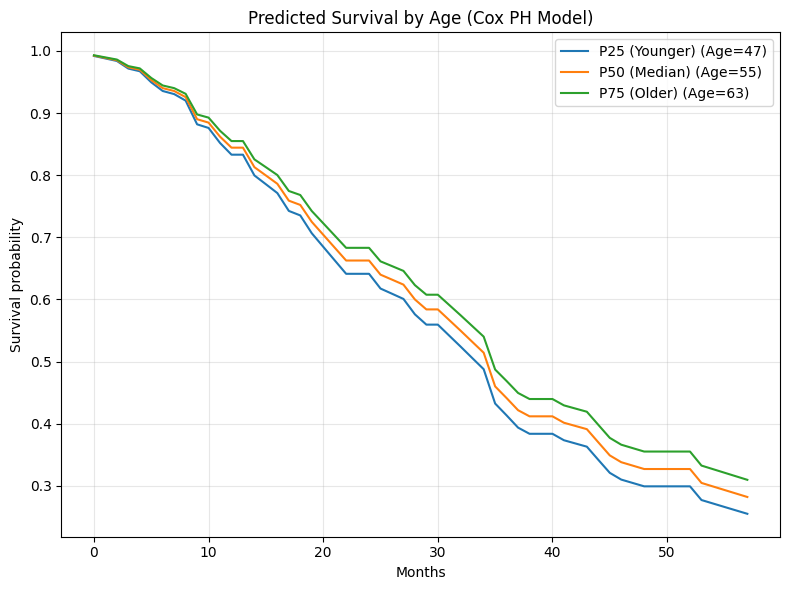

In [19]:
# Visualise: predicted survival curves at P25, P50, P75 of Age
fig, ax = plt.subplots(figsize=(8, 6))

age_percentiles = {
    "P25 (Younger)": int(age_cont_df["Age"].quantile(0.25)),
    "P50 (Median)":  int(age_cont_df["Age"].quantile(0.50)),
    "P75 (Older)":   int(age_cont_df["Age"].quantile(0.75)),
}

for label, age_val in age_percentiles.items():
    cph_age.predict_survival_function(
        pd.DataFrame({"Age": [age_val]})
    ).rename(columns={0: f"{label} (Age={age_val})"}).plot(ax=ax)

ax.set_title("Predicted Survival by Age (Cox PH Model)")
ax.set_xlabel("Months")
ax.set_ylabel("Survival probability")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()